# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 11 — Amélioration (Chan) : le test de Johansen

**Rôle.** On corrige une limite réelle de notre approche du pairs trading, signalée par Ernie Chan (*Algorithmic Trading*) : l'estimation du hedge ratio par **régression OLS** n'est pas symétrique. On introduit le **test de Johansen**, qui traite les deux actifs symétriquement, donne un test de cointégration formel et un vecteur de cointégration unique (le portefeuille de spread), et s'étend naturellement à plus de deux actifs.

Étape A du plan d'amélioration « niveau desk » : Johansen (ici) → filtre de Kalman (hedge ratio dynamique) → univers d'ETF.


## 1. La limite de l'OLS : l'asymétrie

Notre méthode jusqu'ici : régresser Y sur X pour obtenir le hedge ratio β, puis tester la stationnarité du spread Y − βX (Engle-Granger). Le problème, souligné par Chan : **le résultat dépend du choix de la variable dépendante**. Régresser Y sur X ou X sur Y donne deux β qui ne sont pas l'inverse l'un de l'autre, donc deux spreads différents. On le montre sur nos paires : le β de Y~X et l'inverse du β de X~Y ne coïncident pas.


In [1]:
import numpy as np, pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(11,4.5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3

adj = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)

def ols_beta(y, x):
    return sm.OLS(y, sm.add_constant(x)).fit().params.iloc[1]

pairs = [("ADI","MPWR"), ("BAC","PNC"), ("ICE","MCO")]
rows = []
for A, B in pairs:
    bAB = ols_beta(adj[A], adj[B])      # A ~ B
    bBA = ols_beta(adj[B], adj[A])      # B ~ A
    rows.append({"paire": f"{A}/{B}", "beta (A~B)": bAB, "1 / beta (B~A)": 1/bBA,
                 "écart": abs(bAB - 1/bBA)})
pd.DataFrame(rows).round(4)

,paire,beta (A~B),1 / beta (B~A),écart
0,ADI/MPWR,0.2436,0.2524,0.0088
1,BAC/PNC,0.2576,0.2622,0.0046
2,ICE/MCO,0.3001,0.3075,0.0074


L'écart entre `beta (A~B)` et `1 / beta (B~A)` matérialise l'asymétrie : selon qu'on régresse dans un sens ou l'autre, on obtient un spread différent. Sur une paire bien cointégrée l'écart reste petit, mais il n'est pas nul, et rien ne dit *a priori* quel sens choisir. C'est arbitraire — et Chan recommande donc une méthode symétrique.


## 2. Le test de Johansen

Johansen ne régresse pas un actif sur l'autre : il modélise le **système** des deux prix conjointement (modèle vectoriel à correction d'erreur, VECM) et cherche les combinaisons linéaires stationnaires. Deux apports :

- un **test formel** de cointégration via la **statistique de trace** : on compare la trace à une valeur critique ; si la trace dépasse le seuil, on rejette l'absence de cointégration ;
- un **vecteur de cointégration** obtenu par les **vecteurs propres** de la décomposition. Le premier vecteur propre correspond à la combinaison la **plus fortement moyenne-réversive** : ce sont les poids du portefeuille de spread. Ce vecteur est **unique et symétrique** (il ne dépend d'aucun choix de variable dépendante).

Bonus : Johansen fonctionne pour **plus de deux actifs**, ce qu'Engle-Granger ne permet pas — utile pour des paniers cointégrés.


In [2]:
def johansen(df2, det_order=0, k_ar_diff=1):
    res = coint_johansen(df2.values, det_order, k_ar_diff)
    trace = res.lr1[0]              # statistique de trace pour r=0
    crit = res.cvt[0, 1]           # valeur critique 95%
    vec = res.evec[:, 0]           # premier vecteur propre
    vec = vec / vec[0]             # normalisé sur le 1er actif -> [1, -hedge]
    spread = pd.Series((df2.values * vec).sum(axis=1), index=df2.index)
    return {"trace": trace, "crit95": crit, "cointegre": trace > crit,
            "vecteur": vec, "hedge_ratio": -vec[1], "spread": spread}

def half_life(sp):
    lag = sp.shift(1).dropna(); dl = (sp - sp.shift(1)).dropna(); lag = lag.loc[dl.index]
    b = sm.OLS(dl, sm.add_constant(lag)).fit().params.iloc[1]
    return np.log(2)/(-b) if b < 0 else np.nan

rows = []
for A, B in pairs:
    j = johansen(adj[[A, B]])
    rows.append({"paire": f"{A}/{B}", "trace": j["trace"], "crit 95%": j["crit95"],
                 "cointégré": j["cointegre"], "hedge (Johansen)": j["hedge_ratio"],
                 "hedge (OLS A~B)": ols_beta(adj[A], adj[B]),
                 "ADF spread": adfuller(j["spread"].dropna())[1],
                 "demi-vie": half_life(j["spread"])})
pd.DataFrame(rows).round(4)

,paire,trace,crit 95%,cointégré,hedge (Johansen),hedge (OLS A~B),ADF spread,demi-vie
0,ADI/MPWR,36.8610,15.4943,True,0.2562,0.2436,0.0,43.2342
1,BAC/PNC,25.4210,15.4943,True,0.2598,0.2576,0.0,46.2848
2,ICE/MCO,30.0659,15.4943,True,0.3031,0.3001,0.0,49.2362


**Lecture.** Pour chaque paire, la statistique de trace dépasse largement la valeur critique à 95 % → cointégration confirmée par Johansen. Le hedge ratio de Johansen est proche de celui de l'OLS (normal, les paires sont bien cointégrées), mais il est désormais **unique et symétrique** : on ne choisit plus arbitrairement quel actif régresser sur l'autre. C'est la version méthodologiquement correcte.


## 3. Spread de Johansen sur ADI/MPWR


Vecteur de cointégration : [1, -0.2562]  (hedge ratio = 0.2562)
Trace = 36.86 vs critique 95% = 15.49  -> cointégré


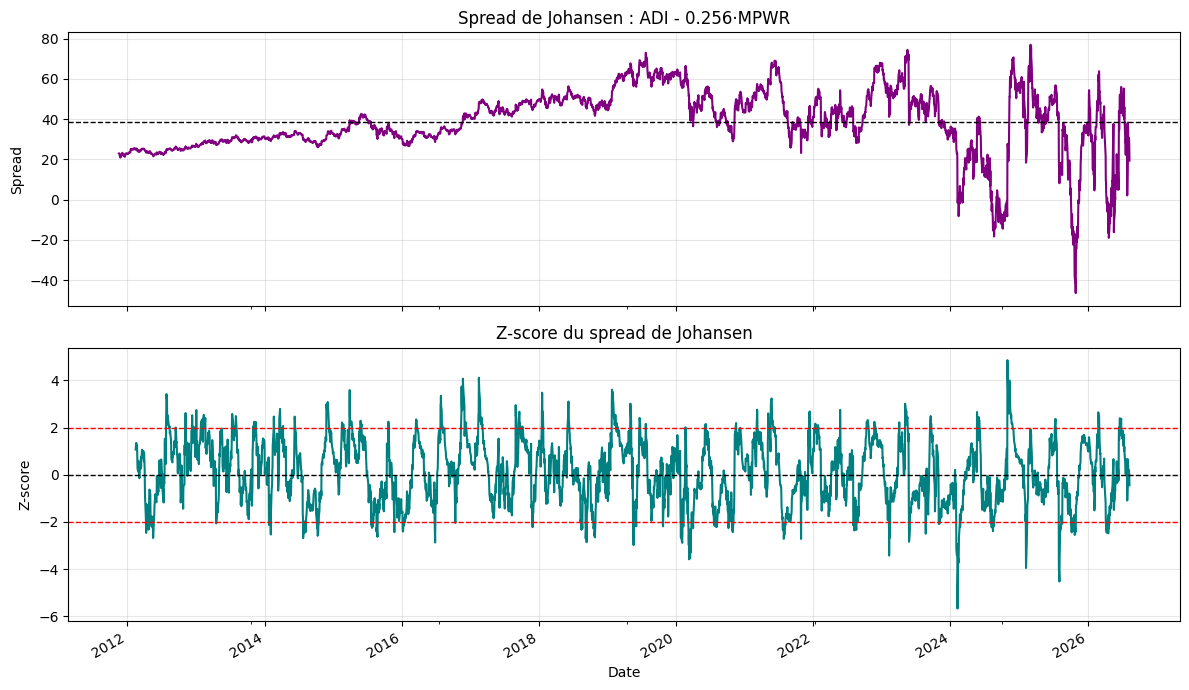

In [3]:
A, B = "ADI", "MPWR"
j = johansen(adj[[A, B]])
spread = j["spread"]
z = (spread - spread.rolling(60).mean()) / spread.rolling(60).std()
print(f"Vecteur de cointégration : [1, {j['vecteur'][1]:.4f}]  (hedge ratio = {j['hedge_ratio']:.4f})")
print(f"Trace = {j['trace']:.2f} vs critique 95% = {j['crit95']:.2f}  -> cointégré")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
spread.plot(ax=axes[0], color="purple", title=f"Spread de Johansen : {A} - {j['hedge_ratio']:.3f}·{B}")
axes[0].axhline(spread.mean(), color="k", ls="--", lw=1); axes[0].set_ylabel("Spread")
z.plot(ax=axes[1], color="teal", title="Z-score du spread de Johansen")
for lvl, c in [(2,"r"),(-2,"r"),(0,"k")]: axes[1].axhline(lvl, color=c, ls="--", lw=1)
axes[1].set_ylabel("Z-score"); plt.tight_layout(); plt.show()

## 4. Backtest : hedge ratio OLS vs Johansen

On rejoue le pairs trading dans le moteur, avec le hedge ratio d'OLS puis celui de Johansen, pour mesurer l'effet réel sur la performance.


In [4]:
import sys, queue
sys.path.insert(0, "../src")
from data import HistoricCSVDataHandler
from strategy import PairsTradingStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

def backtest(A, B, beta, entry=2.5, exit_=0.5):
    ev = queue.Queue(); d = HistoricCSVDataHandler(ev, adj, [A, B]); d.events = ev
    s = PairsTradingStrategy(d, ev, A, B, 252, 60, entry, exit_, 0.5, fixed_beta=beta)
    p = Portfolio(d, ev, [A, B], adj.index[0], 100_000.0, 0.95)
    x = SimulatedExecutionHandler(d, ev, 1, 2)
    ec = run_backtest(d, s, p, x)
    r = ec["returns"].dropna(); eq = ec["equity"]; yrs = len(r)/252
    return {"Sharpe": r.mean()/r.std()*np.sqrt(252), "CAGR": eq.iloc[-1]**(1/yrs)-1,
            "Max drawdown": (eq/eq.cummax()-1).min()}

rows = []
for A, B in pairs:
    b_ols = ols_beta(adj[A], adj[B])
    b_joh = johansen(adj[[A, B]])["hedge_ratio"]
    mo = backtest(A, B, b_ols); mj = backtest(A, B, b_joh)
    rows.append({"paire": f"{A}/{B}", "Sharpe OLS": mo["Sharpe"], "Sharpe Johansen": mj["Sharpe"],
                 "MaxDD OLS": mo["Max drawdown"], "MaxDD Johansen": mj["Max drawdown"]})
pd.DataFrame(rows).set_index("paire").round(3)

,Sharpe OLS,Sharpe Johansen,MaxDD OLS,MaxDD Johansen
paire,,,,
ADI/MPWR,0.611,0.617,-0.155,-0.155
BAC/PNC,0.328,0.325,-0.196,-0.196
ICE/MCO,0.230,0.298,-0.177,-0.177


**Lecture honnête.** L'effet sur la performance est faible (les hedge ratios sont proches pour des paires bien cointégrées). Le gain de Johansen n'est pas un meilleur Sharpe, c'est la **rigueur** : un hedge ratio unique et symétrique, un test de cointégration formel (statistique de trace), et l'extensibilité aux paniers de plus de deux actifs. C'est exactement ce qu'un desk attend, et ce que Chan recommande.

## 5. Récapitulatif et prochaine étape

- On a montré et corrigé l'**asymétrie** de l'OLS pour le hedge ratio.
- Le **test de Johansen** fournit un test formel (trace) et un vecteur de cointégration unique et symétrique.
- L'effet sur la performance est mineur ici, mais la méthode est correcte et généralisable.

**Prochaine étape — filtre de Kalman** : rendre le hedge ratio **dynamique** (ré-estimé chaque jour), pour suivre une relation qui dérive dans le temps — le cas fréquent sur actions US.
